   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 kB 913.4 kB/s eta 0:00:00


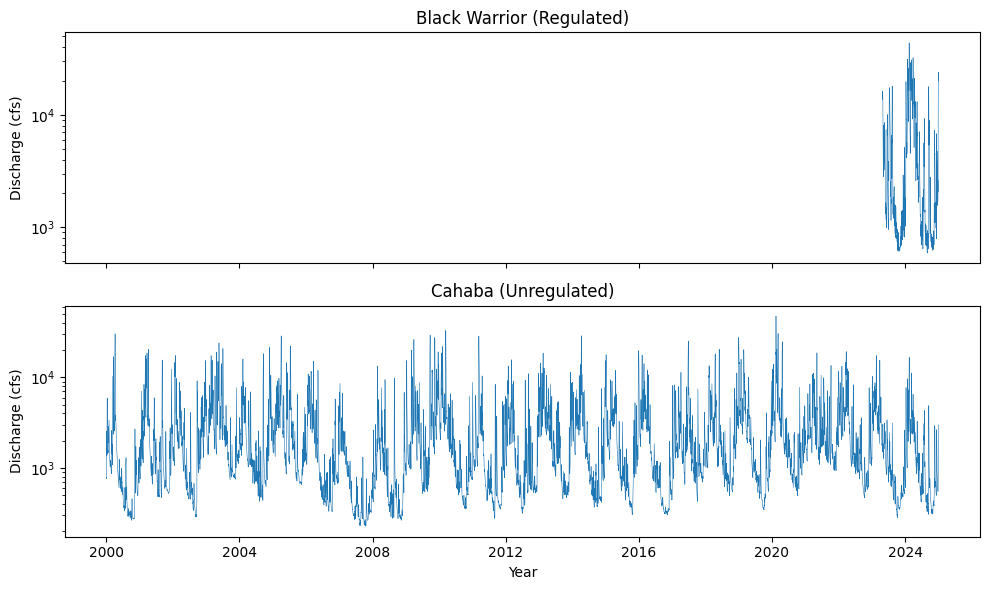

In [3]:
!pip install dataretrieval
import pandas as pd
import matplotlib.pyplot as plt
import dataretrieval.nwis as nwis

# -----------------------------
# USGS gauge IDs
# -----------------------------
gauges = {
    "Black Warrior (Regulated)": "02466031",  # Selden L&D tailwater
    "Cahaba (Unregulated)": "02425000"        # Centreville
}

# Study period
start_date = "2000-01-01"
end_date = "2024-12-31"

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for ax, (label, site) in zip(axes, gauges.items()):
    df = nwis.get_record(
        sites=site,
        service="dv",
        start=start_date,
        end=end_date,
        parameterCd="00060"  # discharge (cfs)
    )

    df = df.reset_index()
    df["datetime"] = pd.to_datetime(df["datetime"])

    ax.plot(df["datetime"], df["00060_Mean"], linewidth=0.4)
    ax.set_yscale("log")
    ax.set_ylabel("Discharge (cfs)")
    ax.set_title(label)

axes[-1].set_xlabel("Year")

plt.tight_layout()
plt.savefig("daily_discharge_timeseries.png", dpi=300)
plt.show()

In [4]:
import pandas as pd
import dataretrieval.nwis as nwis

site = "02466031"  # change to 02425000 for Cahaba

df = nwis.get_record(
    sites=site,
    service="dv",
    start="2000-01-01",
    end="2024-12-31",
    parameterCd="00060"
)

df = df.reset_index()
df["year"] = df["datetime"].dt.year

qcv = df["00060_Mean"].std() / df["00060_Mean"].mean()
print(f"Qcv = {qcv:.2f}")

Qcv = 1.35
